In [43]:
import numpy as np
from space_exploration.beans.dataset_bean import Dataset
from space_exploration.dataset.transforms.AllTransforms import TransformationReferences
dataset_name = "re200-sr05etot"
dataset = Dataset.get_dataset_or_fail(dataset_name)
ds = dataset.get_training_dataset(64, TransformationReferences.COMPONENT_NORMALIZE.transformation, TransformationReferences.Y_ALONG_COMPONENT_NORMALIZE.transformation, size=20000)
xs = np.array([x.numpy() for x, y in ds])
ys = np.array([y.numpy() for x, y in ds])

Loading std & mean of dataset re200-sr05etot
Loading stds & means of dataset re200-sr05etot
⌛ Initializing Dataset...
X...
[########################################] | 100% Completed | 8.67 ss
Y...
[########################################] | 100% Completed | 127.52 s


In [27]:
import torch
import torch.nn.functional as F

def get_gaussian_kernel2d(kernel_size=5, sigma=1.0, device='cpu'):
    coords = torch.arange(kernel_size, dtype=torch.float32, device=device) - kernel_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g /= g.sum()
    g2d = g[:, None] * g[None, :]  # outer product for 2D kernel
    g2d = g2d.unsqueeze(0).unsqueeze(0)  # shape (1,1,k,k)
    return g2d

def apply_dog_2d(images, sigma1=1.0, sigma2=2.0, kernel_size=9):
    """
    ys: torch.Tensor of shape (B, C, H, W)
    returns: DoG-filtered tensor, same shape
    """
    B, C, H, W = images.shape
    device = images.device
    
    # Get both Gaussian kernels
    g1 = get_gaussian_kernel2d(kernel_size, sigma1, device=device)
    g2 = get_gaussian_kernel2d(kernel_size, sigma2, device=device)
    
    # Depthwise convolution for both sigmas
    blurred1 = F.conv2d(images, g1, padding="same")
    blurred2 = F.conv2d(images, g2, padding="same")

    # Difference of Gaussians
    return blurred1 - blurred2

def dog_torch(images, s1, s2):
    # images: B, 1, 64, 64
    x = torch.tensor(images, device="cuda")
    return apply_dog_2d(x, sigma1=s1, sigma2=s2, kernel_size=63).cpu().numpy()



In [17]:
from scipy.ndimage import gaussian_filter

def dog_scipy(images, s1, s2):
    # images shape: B, 1, 64, 64
    return np.array([gaussian_filter(img, s1) - gaussian_filter(img, s2) for img in images.squeeze()])



In [38]:
samples = xs[:20000, :1, :, 0, :]

In [68]:
iter_amount = 50
import timeit
import random
import pandas as pd
import tqdm

results = []
input_sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 20000]
for i in range(iter_amount):
    for size in tqdm.tqdm(input_sizes):
        results.append({"i": i, "size": size, "mtd":"scipy", "time": timeit.timeit(lambda: dog_scipy(samples[:size], 10, 25), number=1)})
        results.append({"i": i, "size": size, "mtd":"torch", "time": timeit.timeit(lambda: dog_torch(samples[:size], 10, 25) ,number=1)})


results = pd.DataFrame(results)


100%|█████████████████████████████████████████████| 8/8 [00:05<00:00,  1.51it/s]


[None]

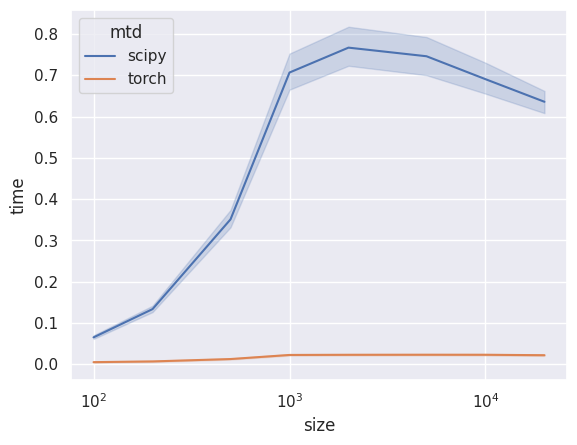

In [69]:
import seaborn as sns
sns.set_theme(style="darkgrid")
plot = sns.lineplot(x="size", y="time",
             hue="mtd",
             data=results)
plot.set(xscale='log')

In [70]:
results.to_csv('torch_dog_benchmark.csv', index=False) 